# Tasas de captación: traspaso de la TPM y costo de fondeo de los bancos

**Pregunta.** ¿Cuánto y qué tan rápido traspasan los bancos chilenos los cambios de la TPM a las tasas de sus depósitos? ¿Anticipa la curva corta de captación los movimientos de la TPM? ¿Qué bancos se financian más barato?

**Datos.** Tasas de depósitos a plazo por tramo de plazo publicadas por la CMF en su API BEST, mensuales desde 2014, y tasas de depósitos de 30 a 60 días por banco en los últimos doce meses. La TPM viene del Banco Central de Chile a través de mindicador.cl.

**Por qué importa.** En gestión de balance y en riesgo de tasa de interés del libro de banca (IRRBB), la fracción de un cambio de la TPM que se traspasa a los depósitos se llama **beta de depósitos**. Es uno de los supuestos que más pesan al medir cómo cambia el margen financiero de un banco cuando se mueven las tasas.

**Resultado principal.** Los depósitos traspasan entre 72% y 90% de los cambios de la TPM en unos tres meses, algo más en los plazos de 30 a 90 días. El traspaso es igual en alzas y en bajas. El tramo corto casi no anticipa la TPM, porque su pendiente refleja sobre todo un premio por plazo. Entre bancos, el costo de fondeo depende más del tamaño que del modelo de negocio: los bancos grandes captan bajo la TPM y los pequeños pagan sobre ella.

## 1. Configuración y datos

In [1]:
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from dsaplicado import cmf, datos, tasas
from dsaplicado.graficos import (
    AZUL_SECUENCIAL, COLORES, NEUTRO, TINTA, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo,
)

aplicar_estilo()
pd.set_option("display.float_format", "{:.2f}".format)

RAIZ = datos.raiz_repositorio()
CACHE = RAIZ / "datos" / "cmf"
FIGURAS = RAIZ / "02_finanzas" / "figuras"

# Los datos quedan en caché. Solo la primera ejecución consulta la API y requiere la clave.
sistema = cmf.cargar_cuadro("CMF_DEPCAP_PLZ_TASA", date(2014, 1, 1), date(2026, 7, 31), CACHE)
flujos = cmf.cargar_cuadro("CMF_DEPCAP_PLZ_$", date(2025, 8, 1), date(2026, 7, 31), CACHE)
por_banco = pd.read_csv(CACHE / "CMF_DEPCAP_DEP_30H60D_BANCOS_202508_202607.csv", parse_dates=["fecha"])
grupos = pd.read_csv(RAIZ / "01_analisis_de_datos" / "resultados" / "grupos_bancos.csv")

tpm = datos.cargar_indicador(RAIZ / "datos" / "tpm_historico.csv", "tpm", range(2001, 2027))
tpm = tpm.mask(tpm < 0.25).ffill()         # corrige el 0% erróneo de julio de 2020
tpm_media = tpm.resample("MS").mean()      # promedio del mes, comparable con tasas promedio de depósitos
tpm_fin = tpm.resample("MS").last()        # valor al cierre del mes, para medir cambios de política

TRAMOS = {"Menos de 15 días": "<15 días", "Desde 15 días y menos de 30 días": "15-30 días",
          "Desde 30 días y menos de 60 días": "30-60 días", "Desde 60 días y menos de 90 días": "60-90 días",
          "Desde 90 días y menos de 180 días": "90-180 días", "Desde 180 días y hasta 1 año": "180 días-1 año",
          "Mayor a 1 año": "Más de 1 año"}
tasas_sistema = sistema.pivot(index="fecha", columns="nombre", values="valor").rename(columns=TRAMOS)[list(TRAMOS.values())]
print(f"Tasas del sistema: {len(tasas_sistema)} meses, de {tasas_sistema.index[0]:%m-%Y} a {tasas_sistema.index[-1]:%m-%Y}")

Tasas del sistema: 150 meses, de 01-2014 a 06-2026


## 2. Qué tramos sirven y por qué

La CMF publica las tasas por plazo sumando depósitos en pesos y en UF. Los depósitos en UF pagan una tasa real, mucho menor que la nominal, y en Chile exigen un plazo mínimo de 90 días. Por eso los tramos desde 90 días en adelante mezclan tasas nominales con tasas reales, y no son comparables con la TPM. Los cuatro tramos menores a 90 días son tasas nominales en pesos.

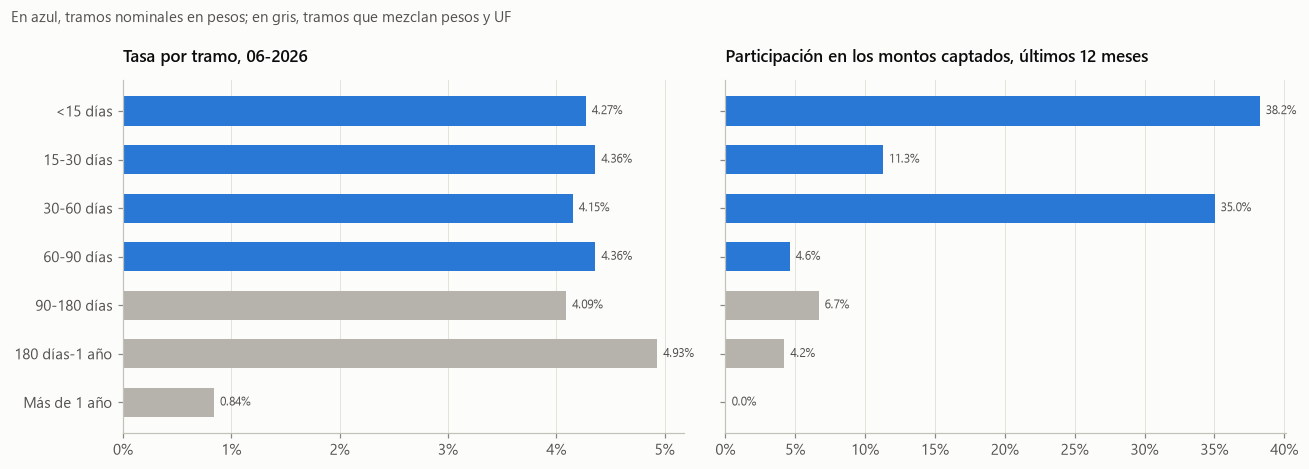

Los tramos menores a 90 días concentran el 89% de los montos captados.


In [2]:
ultimo = tasas_sistema.iloc[-1]
montos = flujos.pivot(index="fecha", columns="nombre", values="valor").rename(columns=TRAMOS)[list(TRAMOS.values())].sum()
participacion = 100 * montos / montos.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
colores = [COLORES[0]] * 4 + [NEUTRO] * 3
ax1.barh(ultimo.index, ultimo.values, color=colores, height=0.6)
for i, v in enumerate(ultimo.values):
    ax1.annotate(f"{v:.2f}%", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8,
                 color=TINTA_SECUNDARIA)
ax1.set_title(f"Tasa por tramo, {tasas_sistema.index[-1]:%m-%Y}", fontsize=11)
ax1.invert_yaxis()
ax2.barh(participacion.index, participacion.values, color=colores, height=0.6)
for i, v in enumerate(participacion.values):
    ax2.annotate(f"{v:.1f}%", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8,
                 color=TINTA_SECUNDARIA)
ax2.set_title("Participación en los montos captados, últimos 12 meses", fontsize=11)
for ax in (ax1, ax2):
    ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
fig.suptitle("En azul, tramos nominales en pesos; en gris, tramos que mezclan pesos y UF", x=0.01, ha="left",
             fontsize=10, color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()
print(f"Los tramos menores a 90 días concentran el {participacion.iloc[:4].sum():.0f}% de los montos captados.")

El tramo de más de un año muestra una tasa inferior a 1%, algo imposible para un depósito nominal con la TPM sobre 4%. Es la huella de los depósitos en UF. Además, casi todo el dinero se capta a menos de 90 días, así que el tramo corto es el que determina el costo de fondeo de los bancos. El resto del análisis usa solo los cuatro tramos nominales.

## 3. Tasas de depósito y TPM desde 2014

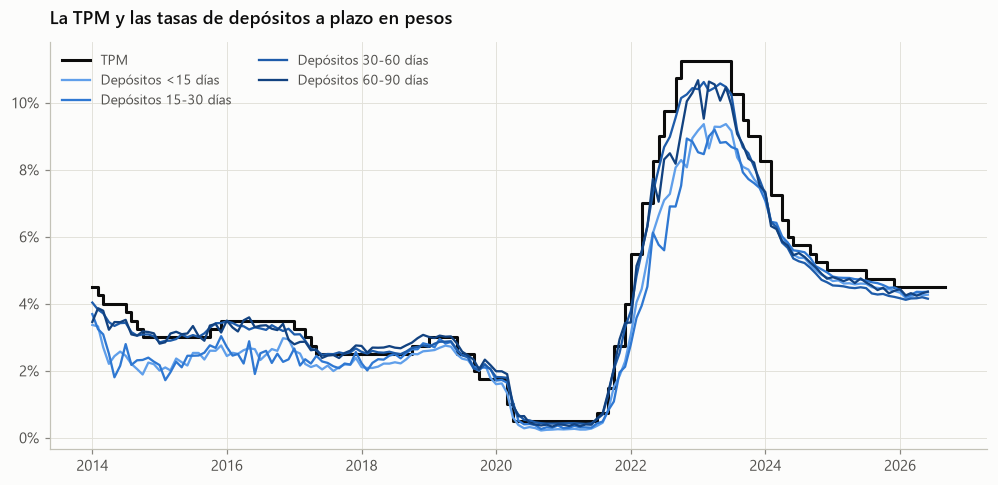

In [3]:
CORTOS = ["<15 días", "15-30 días", "30-60 días", "60-90 días"]
cortos = tasas_sistema[CORTOS]
rampa = [AZUL_SECUENCIAL(x) for x in (0.3, 0.5, 0.7, 0.9)]

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.step(tpm_fin.loc["2014":].index, tpm_fin.loc["2014":], where="post", color=TINTA, linewidth=2, label="TPM")
for tramo, color in zip(CORTOS, rampa):
    ax.plot(cortos.index, cortos[tramo], color=color, linewidth=1.5, label=f"Depósitos {tramo}")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("La TPM y las tasas de depósitos a plazo en pesos")
ax.legend(loc="upper left", ncols=2, fontsize=9)
plt.show()

Las tasas de depósito siguen a la TPM de cerca en los tres ciclos de la muestra: los recortes de 2019 y 2020, el alza de 2021 y 2022, y los recortes desde mediados de 2023. La diferencia más visible aparece en el peak: cuando la TPM llegó a 11,25%, los depósitos quedaron claramente por debajo.

### Margen de los depósitos sobre la TPM

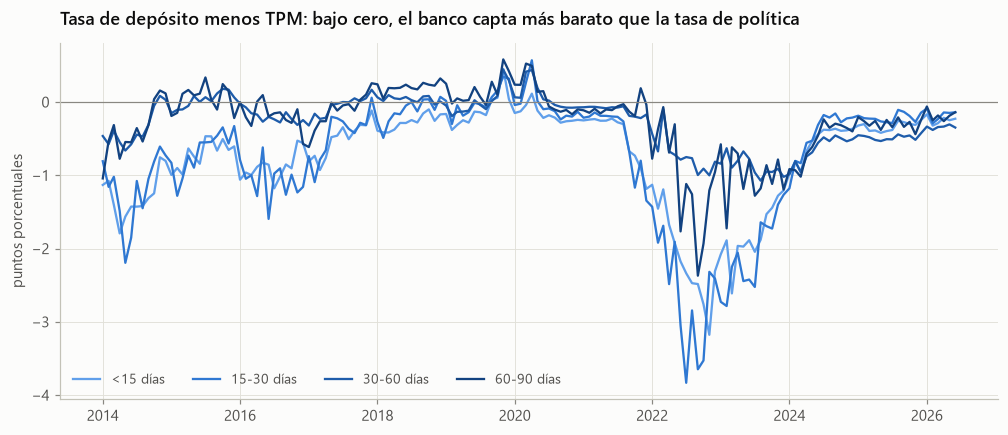

nombre,<15 días,15-30 días,30-60 días,60-90 días
fecha,,,,
2014,-1.28,-1.19,-0.36,-0.39
2015,-0.71,-0.68,0.02,0.05
2016,-0.89,-1.07,-0.19,-0.18
2017,-0.51,-0.44,-0.06,-0.12
2018,-0.28,-0.12,0.04,0.21
2019,-0.10,0.01,0.01,0.16
2020,-0.16,-0.02,0.07,0.09
2021,-0.46,-0.47,-0.11,-0.08
2022,-2.09,-2.59,-0.72,-1.07


In [4]:
margen = cortos.sub(tpm_media, axis=0).dropna()
fig, ax = plt.subplots(figsize=(11, 4.2))
for tramo, color in zip(CORTOS, rampa):
    ax.plot(margen.index, margen[tramo], color=color, linewidth=1.5, label=tramo)
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_ylabel("puntos porcentuales")
ax.set_title("Tasa de depósito menos TPM: bajo cero, el banco capta más barato que la tasa de política")
ax.legend(loc="lower left", ncols=4, fontsize=9)
fig.savefig(FIGURAS / "margen_depositos_tpm.png", bbox_inches="tight")
plt.show()
margen.groupby(margen.index.year).mean()

En tiempos normales, los depósitos pagan entre 1 punto bajo la TPM y un nivel muy cercano a ella, y los plazos de 30 a 90 días quedan más cerca de la TPM que los más cortos. En 2022 y 2023 ese margen se abrió a más de 2 puntos en los plazos más cortos: los bancos no traspasaron completas las alzas de tasas y abarataron su fondeo relativo. A medida que la TPM bajó, el margen volvió a su nivel habitual.

## 4. La beta de depósitos

In [5]:
filas = {}
for tramo in CORTOS:
    res = tasas.beta_traspaso(cortos[tramo], tpm_media, rezagos=3)
    asim = tasas.beta_asimetrica(cortos[tramo], tpm_media, rezagos=3)
    filas[tramo] = {"impacto en el mes": res["impacto"], "beta de largo plazo": res["largo_plazo"],
                    "error estándar": res["error_estandar"], "R cuadrado": res["r2"],
                    "beta en alzas": asim["beta_alzas"], "beta en bajas": asim["beta_bajas"],
                    "p igualdad alzas y bajas": asim["p_igualdad"]}
betas = pd.DataFrame(filas).T
betas

,impacto en el mes,beta de largo plazo,error estándar,R cuadrado,beta en alzas,beta en bajas,p igualdad alzas y bajas
<15 días,0.65,0.77,0.04,0.63,0.78,0.74,0.71
15-30 días,0.33,0.72,0.09,0.35,0.72,0.70,0.88
30-60 días,0.69,0.90,0.03,0.87,0.91,0.88,0.68
60-90 días,0.63,0.86,0.09,0.45,0.88,0.81,0.68


In [6]:
CICLOS = {"Recortes 2019-2020": ("2019-05-01", "2020-04-01"),
          "Alzas 2021-2022": ("2021-06-01", "2022-10-01"),
          "Recortes 2023-2025": ("2023-06-01", "2025-01-01")}
ciclos = pd.DataFrame({
    nombre: {"cambio de la TPM": tpm_media.loc[fin] - tpm_media.loc[inicio],
             **{tramo: tasas.beta_ciclo(cortos[tramo], tpm_media, inicio, fin) for tramo in CORTOS}}
    for nombre, (inicio, fin) in CICLOS.items()
}).T
ciclos

,cambio de la TPM,<15 días,15-30 días,30-60 días,60-90 días
Recortes 2019-2020,-2.50,0.84,0.72,0.78,0.81
Alzas 2021-2022,10.55,0.76,0.68,0.92,0.83
Recortes 2023-2025,-6.25,0.75,0.64,0.95,0.91


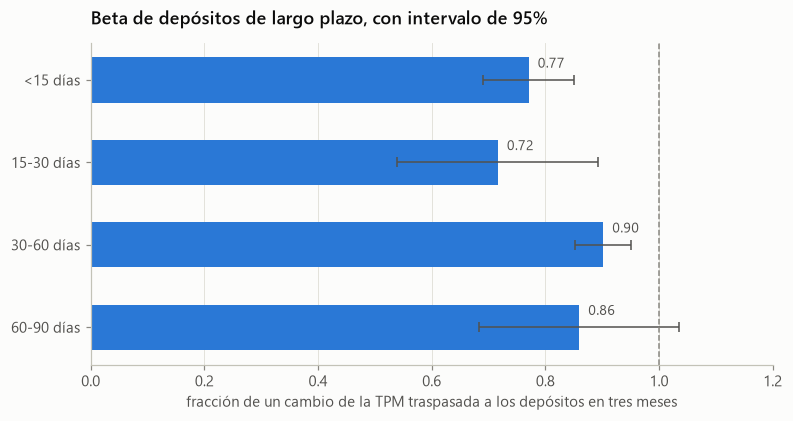

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(CORTOS))
ax.barh(y, betas["beta de largo plazo"], xerr=1.96 * betas["error estándar"], color=COLORES[0], height=0.55,
        error_kw={"ecolor": TINTA_SECUNDARIA, "elinewidth": 1, "capsize": 3})
for i, v in enumerate(betas["beta de largo plazo"]):
    ax.annotate(f"{v:.2f}", (v, i), xytext=(6, 8), textcoords="offset points", fontsize=9, color=TINTA_SECUNDARIA)
ax.axvline(1, color=TINTA_TENUE, linewidth=1, linestyle="--")
ax.set_yticks(y, CORTOS)
ax.invert_yaxis()
ax.set_xlim(0, 1.2)
ax.set_xlabel("fracción de un cambio de la TPM traspasada a los depósitos en tres meses")
ax.set_title("Beta de depósitos de largo plazo, con intervalo de 95%")
ax.grid(axis="y", visible=False)
fig.savefig(FIGURAS / "beta_depositos.png", bbox_inches="tight")
plt.show()

**Lectura.**

- **El traspaso es alto pero incompleto.** Entre 72% y 90% de un cambio de la TPM llega a los depósitos en unos tres meses. En la mayoría de los tramos, cerca de dos tercios del cambio se traspasa en el mismo mes.
- **Los plazos de 30 a 90 días traspasan más.** Los depósitos de menos de 30 días reaccionan menos, probablemente porque incluyen más clientes minoristas, que comparan menos tasas.
- **Sin asimetría.** Las betas en alzas y en bajas son muy parecidas y la prueba no rechaza que sean iguales. Las betas por ciclo confirman el mismo rango.

**Implicancia para IRRBB.** Con una beta cercana a 0,8, si los activos de un banco se reprecian completamente con la TPM, un alza de tasas aumenta su margen financiero, porque sus depósitos solo suben en 80% del cambio. Suponer una beta de 1 exageraría el costo de fondeo en un escenario de alza, y suponer una beta baja lo subestimaría en uno de baja.

## 5. ¿Anticipa el tramo corto los cambios de la TPM?

Según la hipótesis de expectativas, si el mercado espera un alza de la TPM, las tasas a 60 o 90 días deberían subir antes que las de menos de 15 días. Se prueba si la pendiente entre ambos tramos predice el cambio de la TPM en los meses siguientes.

In [8]:
pendiente = (cortos["60-90 días"] - cortos["<15 días"]).rename("pendiente")
filas = {}
for meses in (1, 3, 6):
    cambio_futuro = (tpm_fin.shift(-meses) - tpm_fin).rename("cambio")
    datos_reg = pd.concat([pendiente, cambio_futuro], axis=1, sort=True).dropna()
    ajuste = sm.OLS(datos_reg["cambio"], sm.add_constant(datos_reg["pendiente"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": meses})
    filas[f"{meses} meses"] = {"coeficiente": ajuste.params["pendiente"], "p-valor": ajuste.pvalues["pendiente"],
                               "R cuadrado": ajuste.rsquared, "observaciones": int(ajuste.nobs)}
prediccion = pd.DataFrame(filas).T
print(f"La pendiente fue positiva en el {(pendiente > 0).mean():.0%} de los meses; promedio {pendiente.mean():.2f} puntos.")
prediccion

La pendiente fue positiva en el 93% de los meses; promedio 0.48 puntos.


,coeficiente,p-valor,R cuadrado,observaciones
1 meses,0.20,0.02,0.06,150.00
3 meses,0.46,0.10,0.06,150.00
6 meses,0.52,0.42,0.02,147.00


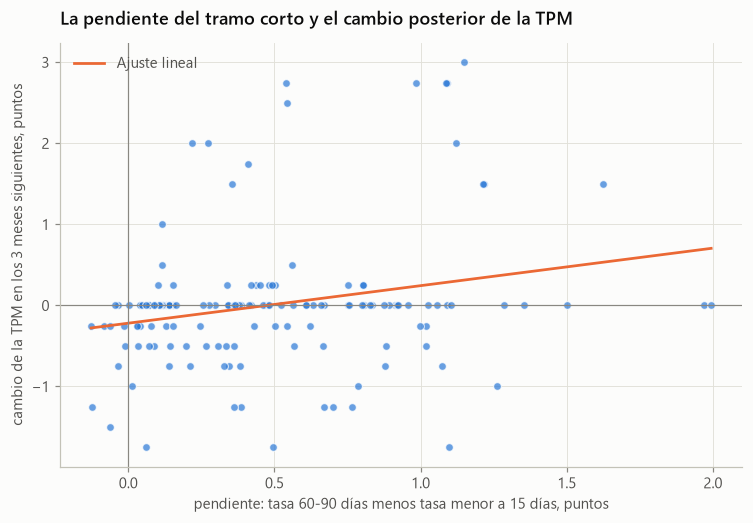

In [9]:
cambio_3m = (tpm_fin.shift(-3) - tpm_fin).rename("cambio")
datos_reg = pd.concat([pendiente, cambio_3m], axis=1, sort=True).dropna()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(datos_reg["pendiente"], datos_reg["cambio"], s=26, color=COLORES[0], alpha=0.7, edgecolor="white", linewidth=0.8)
x = np.linspace(datos_reg["pendiente"].min(), datos_reg["pendiente"].max(), 50)
coef = np.polyfit(datos_reg["pendiente"], datos_reg["cambio"], 1)
ax.plot(x, np.polyval(coef, x), color=COLORES[1], linewidth=1.8, label="Ajuste lineal")
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.axvline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_xlabel("pendiente: tasa 60-90 días menos tasa menor a 15 días, puntos")
ax.set_ylabel("cambio de la TPM en los 3 meses siguientes, puntos")
ax.set_title("La pendiente del tramo corto y el cambio posterior de la TPM")
ax.legend(loc="upper left")
plt.show()

**Lectura.** La relación tiene el signo esperado, pero es débil: la pendiente explica menos del 10% de los cambios futuros de la TPM y la señal pierde significancia más allá de un mes. La pendiente es positiva casi siempre, incluso antes de los recortes, porque los bancos pagan un premio por fondeo más largo. Ese premio domina la señal de expectativas. Para anticipar la TPM son mejores las encuestas de expectativas o los contratos swap de tasas, que no están en esta fuente.

## 6. Costo de fondeo por banco

Se compara la tasa que paga cada banco por depósitos de 30 a 60 días con la TPM promedio del mismo mes. Los grupos vienen del [notebook de segmentación](../01_analisis_de_datos/01_segmentacion_bancos.ipynb).

In [10]:
por_banco["codigo"] = por_banco["codigo_serie"].map(cmf.codigo_institucion)
por_banco = por_banco.join(tpm_media.rename("tpm"), on="fecha")
por_banco["margen"] = por_banco["valor"] - por_banco["tpm"]
costo = (por_banco.groupby("codigo")
         .agg(tasa=("valor", "mean"), margen=("margen", "mean"), meses=("valor", "size"))
         .join(grupos.set_index("codigo")))
MESES_MINIMOS = 6
print("Bancos con menos de", MESES_MINIMOS, "meses de datos, excluidos del ranking:",
      ", ".join(costo.index[costo["meses"] < MESES_MINIMOS].map(dict(zip(grupos["codigo"], grupos["banco"])))))
costo = costo[costo["meses"] >= MESES_MINIMOS].sort_values("margen")
costo[["banco", "grupo", "tasa", "margen", "meses"]]

Bancos con menos de 6 meses de datos, excluidos del ranking: Security, China Construction, JP Morgan


,banco,grupo,tasa,margen,meses
codigo,,,,,
BECH,BancoEstado,Banca universal,3.58,-1.02,11
BSANT,Santander,Banca universal,3.87,-0.73,11
BFALA,Falabella,Banca de consumo,3.91,-0.69,11
BCHI,Banco de Chile,Banca universal,4.07,-0.53,11
HSBC,HSBC,Banca mayorista extranjera,4.29,-0.32,11
BCI,BCI,Banca universal,4.42,-0.18,11
BITAUCORP,Itaú,Banca universal,4.58,-0.02,11
BICE,BICE,Banca universal,4.71,0.11,11
BSCOT,Scotiabank,Banca universal,4.75,0.15,11


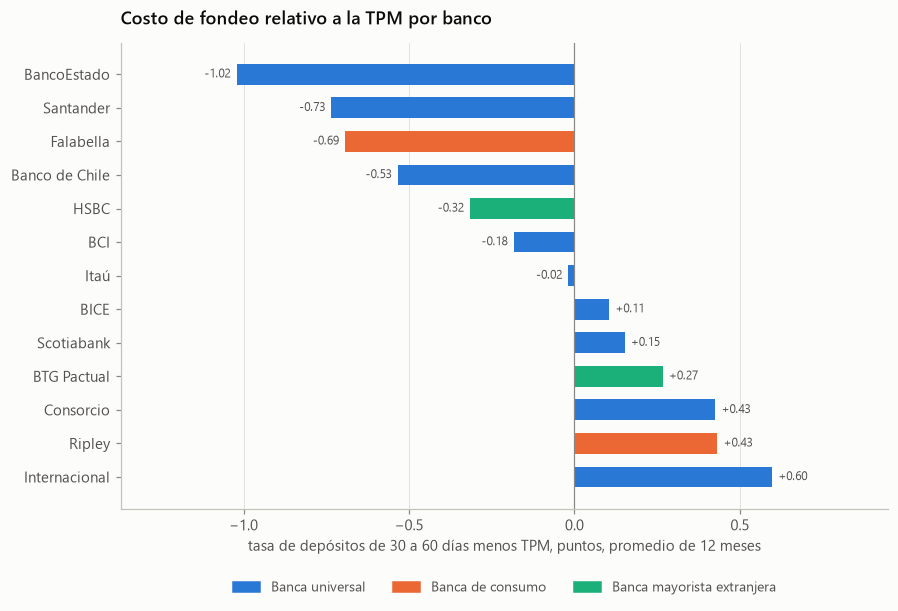

In [11]:
COLOR_GRUPO = {"Banca universal": COLORES[0], "Banca de consumo": COLORES[1], "Banca mayorista extranjera": COLORES[2]}
fig, ax = plt.subplots(figsize=(9, 5.5))
from matplotlib.patches import Patch
ax.barh(costo["banco"], costo["margen"], color=costo["grupo"].map(COLOR_GRUPO), height=0.62)
for i, v in enumerate(costo["margen"]):
    ax.annotate(f"{v:+.2f}", (v, i), xytext=(4 if v >= 0 else -4, 0), textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=8, color=TINTA_SECUNDARIA)
ax.axvline(0, color=TINTA_TENUE, linewidth=0.8)
ax.invert_yaxis()
ax.set_xlim(costo["margen"].min() - 0.35, costo["margen"].max() + 0.35)
ax.set_xlabel("tasa de depósitos de 30 a 60 días menos TPM, puntos, promedio de 12 meses")
ax.set_title("Costo de fondeo relativo a la TPM por banco")
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=n) for n, c in COLOR_GRUPO.items()], loc="upper center",
          bbox_to_anchor=(0.5, -0.13), ncols=3, fontsize=9)
fig.savefig(FIGURAS / "costo_fondeo_bancos.png", bbox_inches="tight")
plt.show()

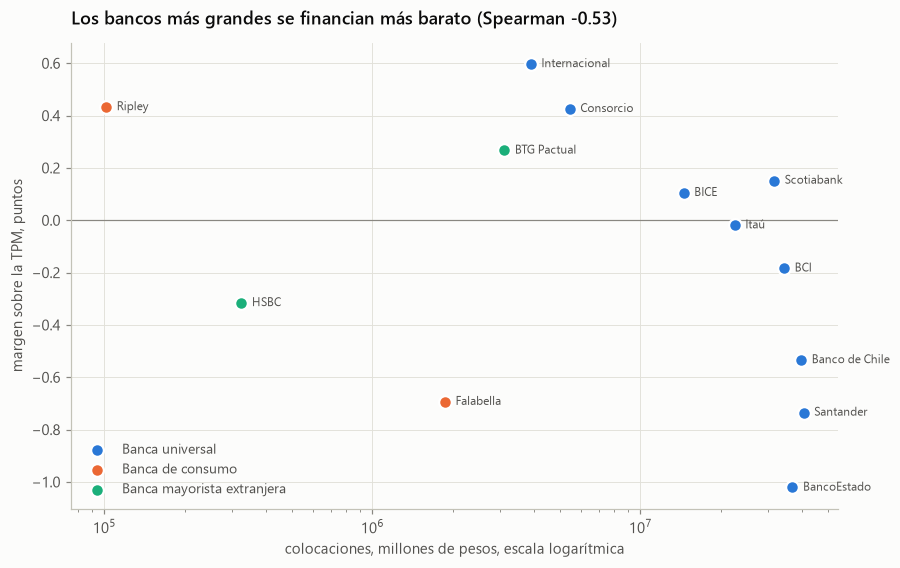

,margen mediano
grupo,
Banca de consumo,-0.13
Banca mayorista extranjera,-0.02
Banca universal,-0.02


In [12]:
colocaciones = cmf.cargar_cuadro("SBIF_CONT_EPLME_ACTIV_COL_AGIFI", date(2025, 8, 1), date(2026, 7, 31), CACHE)
colocaciones["codigo"] = colocaciones["codigo_serie"].map(cmf.codigo_institucion)
tamano = colocaciones.groupby("codigo")["valor"].mean().rename("colocaciones")
costo = costo.join(tamano)

rho = costo[["margen", "colocaciones"]].corr(method="spearman").iloc[0, 1]
fig, ax = plt.subplots(figsize=(9, 5.5))
for nombre, color in COLOR_GRUPO.items():
    puntos = costo[costo["grupo"] == nombre]
    ax.scatter(puntos["colocaciones"], puntos["margen"], s=70, color=color, edgecolor="white", linewidth=1.5,
               label=nombre, zorder=3)
for codigo, fila in costo.iterrows():
    ax.annotate(fila["banco"], (fila["colocaciones"], fila["margen"]), xytext=(7, 0), textcoords="offset points",
                va="center", fontsize=8, color=TINTA_SECUNDARIA)
ax.set_xscale("log")
ax.axhline(0, color=TINTA_TENUE, linewidth=0.8)
ax.set_xlabel("colocaciones, millones de pesos, escala logarítmica")
ax.set_ylabel("margen sobre la TPM, puntos")
ax.set_title(f"Los bancos más grandes se financian más barato (Spearman {rho:.2f})")
ax.legend(loc="lower left", fontsize=9)
plt.show()
costo.groupby("grupo")["margen"].median().rename("margen mediano").to_frame()

**Lectura.**

- **El tamaño pesa más que el grupo.** Las medianas por grupo son casi iguales, pero dentro de cada grupo hay grandes diferencias. La correlación entre tamaño y margen es negativa y relevante: los bancos con más colocaciones captan más barato.
- **Franquicia minorista.** BancoEstado, Santander, Falabella y Banco de Chile captan entre medio y un punto bajo la TPM. Tienen redes amplias de clientes, que dejan su dinero a tasas menores.
- **Bancos pequeños pagan un premio.** Internacional, Consorcio y Ripley pagan sobre la TPM para atraer depósitos, lo que presiona su margen financiero.

## 7. Conclusiones

1. **Beta de depósitos entre 0,72 y 0,90.** Los bancos traspasan la mayor parte de los cambios de la TPM a sus depósitos en unos tres meses, sin diferencias entre alzas y bajas.
2. **En los ciclos extremos, el margen se abre.** En 2022 y 2023 los depósitos de menos de 30 días pagaron en promedio más de 2 puntos bajo la TPM, lo que abarató el fondeo relativo de los bancos durante el ciclo de alzas.
3. **El tramo corto no es un buen predictor de la TPM.** Su pendiente refleja sobre todo un premio por plazo.
4. **El costo de fondeo depende del tamaño y la franquicia.** Los bancos grandes con muchos clientes minoristas se financian bajo la TPM, y los pequeños sobre ella.

## 8. Limitaciones

- **Sin curva larga.** La CMF no publica tasas nominales puras sobre 90 días, así que no se puede ajustar una curva completa ni calcular duración o convexidad. Eso requiere la curva de bonos del Banco Central, que se agregará en un proyecto futuro.
- **Moneda.** Los tramos cortos podrían incluir depósitos en moneda extranjera. Su participación es menor, pero la fuente no permite separarlos.
- **Tasas promedio.** Son promedios ponderados por monto de cada mes, no tasas de oferta. Un cambio en la mezcla de clientes puede mover la tasa sin que cambie el precio.
- **Doce meses por banco.** El ranking de costo de fondeo es una foto reciente, y tres bancos quedan fuera por tener pocos meses con datos.